## Dynamics of Financial Correlation Networks in S&P 500 stocks (One-Factor Model)

- Author: Abbinav Sankar Kailasam

In [1]:
# Import necessary libraries

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})
import seaborn as sns

import networkx as nx
from scipy.sparse.csgraph import minimum_spanning_tree

In [2]:
# Function to construct the minimum spanning tree graph from the distance matrix
def mst_graph(D: np.ndarray, stock_names: list[str]):
    mst_sparse = minimum_spanning_tree(D)
    mst_coo = mst_sparse.tocoo()

    G = nx.Graph()
    G.add_nodes_from(stock_names)

    for u, v, w in zip(mst_coo.row, mst_coo.col, mst_coo.data):
        G.add_edge(stock_names[u], stock_names[v], weight=float(w), edge_type="mst")
    return G

crisis_periods = {
    'GFC':     ('2007-08-01', '2010-06-18'),
    'COVID-19': ('2020-03-01', '2021-12-01')
}

indices_to_plot = [151, 376, 950]

### Exploratory Data Analysis

In [3]:
df_price = pd.read_csv("data/SP500_AdjClose_Cleaned.csv")
df_price["Date"] = pd.to_datetime(df_price["Date"], format="%Y-%m-%d")

stock_cols = sorted([col for col in df_price.columns if col != "Date"], key=lambda x: x.split("_")[0])
df_price = df_price[["Date"] + stock_cols]

df_index = pd.read_csv("data/SP500_Index_Cleaned.csv")
df_index["Date"] = pd.to_datetime(df_index["Date"], format="%Y-%m-%d")

df_price.head()

,Date,CD_AMZN,CD_AZO,CD_BBY,CD_BKNG,CD_CCL,CD_DECK,CD_DRI,CD_DHI,CD_EBAY,...,UTL_FE,UTL_NEE,UTL_NI,UTL_PEG,UTL_PNW,UTL_PPL,UTL_SO,UTL_SRE,UTL_WEC,UTL_XEL
0,2000-01-03,4.468750,30.5625,13.958043,301.860870,28.642263,0.145833,5.591213,2.616618,6.591352,...,6.855634,2.242677,2.378940,5.910198,9.416950,3.422152,4.231557,3.543866,4.081885,6.529201
1,2000-01-04,4.096875,30.4375,13.867408,318.058289,28.298550,0.140625,5.550847,2.517878,5.973049,...,6.855634,2.283453,2.404250,5.953575,9.535655,3.508911,4.278057,3.582246,4.108653,6.679542
2,2000-01-05,3.487500,30.3125,13.776765,353.029968,29.253307,0.142361,5.752693,2.554905,6.372612,...,7.108109,2.358209,2.505480,6.105400,9.792841,3.586028,4.498936,3.659009,4.296017,6.937274
3,2000-01-06,3.278125,29.0625,13.655912,338.673187,29.673395,0.154514,5.692140,2.419138,6.293866,...,7.127528,2.358209,2.488608,6.127087,9.852191,3.537827,4.510560,3.761361,4.282635,6.872839
4,2000-01-07,3.478125,30.4375,14.078887,337.200714,29.329681,0.149306,5.611400,2.505535,6.288032,...,7.166372,2.426167,2.480172,6.083711,10.129162,3.605309,4.591936,3.684598,4.336169,6.872839


In [4]:
df_logreturns = pd.DataFrame()
df_logreturns["Date"] = df_price["Date"]

for col in df_price.columns[1:]:
    df_logreturns[col] = np.log(df_price[col]) - np.log(df_price[col].shift(1))

df_logreturns = df_logreturns.dropna(how="any", axis=0).reset_index(drop=True)
df_logreturns["INDEX"] = df_index["LogReturns"].values

df_logreturns.head()

C:\Users\Abbin\AppData\Local\Temp\ipykernel_13408\209807886.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_logreturns[col] = np.log(df_price[col]) - np.log(df_price[col].shift(1))
C:\Users\Abbin\AppData\Local\Temp\ipykernel_13408\209807886.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_logreturns[col] = np.log(df_price[col]) - np.log(df_price[col].shift(1))
C:\Users\Abbin\AppData\Local\Temp\ipykernel_13408\209807886.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

,Date,CD_AMZN,CD_AZO,CD_BBY,CD_BKNG,CD_CCL,CD_DECK,CD_DRI,CD_DHI,CD_EBAY,...,UTL_NEE,UTL_NI,UTL_PEG,UTL_PNW,UTL_PPL,UTL_SO,UTL_SRE,UTL_WEC,UTL_XEL,INDEX
0,2000-01-04,-0.086884,-0.004098,-0.006515,0.052268,-0.012073,-0.036365,-0.007246,-0.038466,-0.098501,...,0.018018,0.010583,0.007313,0.012527,0.025036,0.010929,0.010772,0.006536,0.022765,-0.039099
1,2000-01-05,-0.161039,-0.004115,-0.006558,0.104318,0.033182,0.012269,0.035718,0.014599,0.064752,...,0.032214,0.041243,0.025182,0.026614,0.021740,0.050342,0.021202,0.044593,0.037859,0.001920
2,2000-01-06,-0.061914,-0.042111,-0.008811,-0.041517,0.014258,0.081919,-0.010582,-0.054604,-0.012434,...,0.000000,-0.006757,0.003546,0.006042,-0.013532,0.002580,0.027589,-0.003120,-0.009332,0.000955
3,2000-01-07,0.059222,0.046227,0.030504,-0.004357,-0.011651,-0.034287,-0.014286,0.035091,-0.000927,...,0.028410,-0.003395,-0.007105,0.027725,0.018895,0.017880,-0.020619,0.012423,0.000000,0.026730
4,2000-01-10,-0.005405,0.008180,-0.010788,-0.053825,0.043319,-0.072323,0.007169,0.019513,0.054165,...,-0.008438,0.023531,-0.001784,-0.013766,-0.010754,-0.007624,-0.010471,0.000000,0.000000,0.011128


In [5]:
stock_names = df_logreturns.columns[1:-1].tolist()
T = len(df_logreturns)
N = len(stock_names)

df_onefactor_returns = pd.DataFrame()
df_onefactor_returns["Date"] = df_index["Date"].values
for stock in stock_names:
    y = df_logreturns[stock].values
    X = np.vstack([np.ones(T), df_logreturns["INDEX"].values]).T

    alpha, beta = np.linalg.lstsq(X, y, rcond=None)[0]
    residuals = y - (alpha + beta * df_logreturns["INDEX"].values)
    sigma_eps = np.std(residuals)
    eps = np.random.normal(0, sigma_eps, size=T)

    df_onefactor_returns[stock] = alpha + beta * df_logreturns["INDEX"].values + eps

df_onefactor_returns.head()

C:\Users\Abbin\AppData\Local\Temp\ipykernel_13408\2949966009.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_onefactor_returns[stock] = alpha + beta * df_logreturns["INDEX"].values + eps
C:\Users\Abbin\AppData\Local\Temp\ipykernel_13408\2949966009.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_onefactor_returns[stock] = alpha + beta * df_logreturns["INDEX"].values + eps
C:\Users\Abbin\AppData\Local\Temp\ipykernel_13408\2949966009.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

,Date,CD_AMZN,CD_AZO,CD_BBY,CD_BKNG,CD_CCL,CD_DECK,CD_DRI,CD_DHI,CD_EBAY,...,UTL_FE,UTL_NEE,UTL_NI,UTL_PEG,UTL_PNW,UTL_PPL,UTL_SO,UTL_SRE,UTL_WEC,UTL_XEL
0,2000-01-04,-0.028303,-0.009311,-0.055266,-0.061053,-0.042896,-0.032735,-0.029222,-0.031108,-0.096965,...,-0.022796,-0.039822,-0.037604,-0.032148,-0.033158,-0.029649,-0.024375,0.008998,-0.027693,-0.036137
1,2000-01-05,0.053437,-0.003510,-0.010683,0.012058,0.020140,-0.012951,0.005601,-0.008050,0.014292,...,0.008142,0.009210,0.011130,0.024980,-0.021732,0.007040,0.002552,-0.018063,-0.006170,-0.003414
2,2000-01-06,0.000718,-0.000445,-0.013095,0.055073,-0.028589,-0.021043,-0.014630,-0.011449,-0.002704,...,-0.010137,0.010901,0.035503,-0.010096,-0.024108,0.004843,-0.015248,0.001082,0.002668,-0.000785
3,2000-01-07,-0.036050,0.000531,0.018398,0.060426,0.044330,0.014183,0.018656,0.089647,-0.000462,...,0.020040,0.028522,-0.006560,0.027667,-0.012174,0.011993,0.008716,0.042059,0.002530,0.029811
4,2000-01-10,0.037515,0.000738,0.022946,-0.022856,0.054779,0.023149,0.028392,-0.006256,-0.000512,...,0.006347,0.010321,0.009756,0.006317,0.012599,0.023803,-0.009611,0.023069,0.004370,0.012548


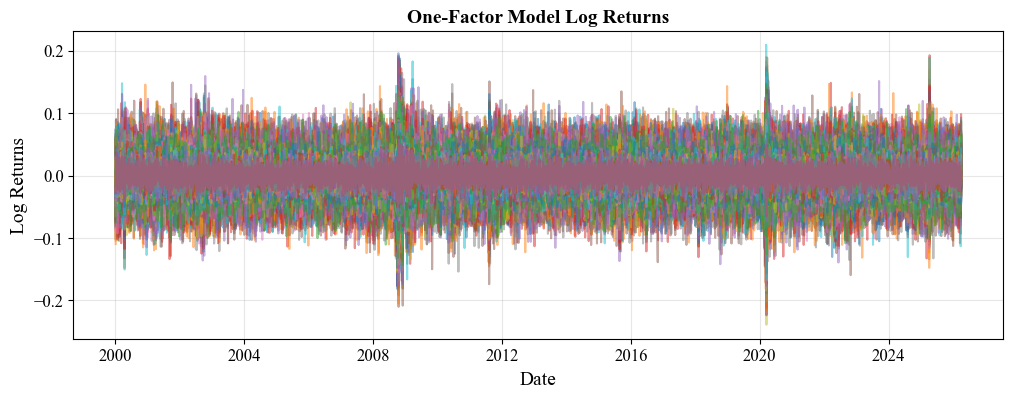

In [6]:
plt.figure(figsize=(12, 4))
for col in df_onefactor_returns.columns[1:]:
    plt.plot(df_onefactor_returns["Date"], df_onefactor_returns[col], alpha=0.5)

plt.title("One-Factor Model Log Returns", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Log Returns", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [7]:
epoch_length = 750
epoch_shift = 5

correlation_matrices = []
distance_matrices = []
mu_values = []
epoch_dates = []

for i in range(0, len(df_onefactor_returns) - epoch_length, epoch_shift):
  epoch = df_onefactor_returns.iloc[i:i+epoch_length]

  correlation_matrix = epoch.iloc[:, 1:].corr().values
  distance_matrix = np.sqrt(2 * (1 - correlation_matrix))
  mu = np.mean(correlation_matrix)

  correlation_matrices.append(correlation_matrix)
  distance_matrices.append(distance_matrix)
  mu_values.append(mu)

  epoch_dates.append(epoch["Date"].iloc[-1])

print(correlation_matrices[0].shape)
print(len(correlation_matrices))

(335, 335)
1170


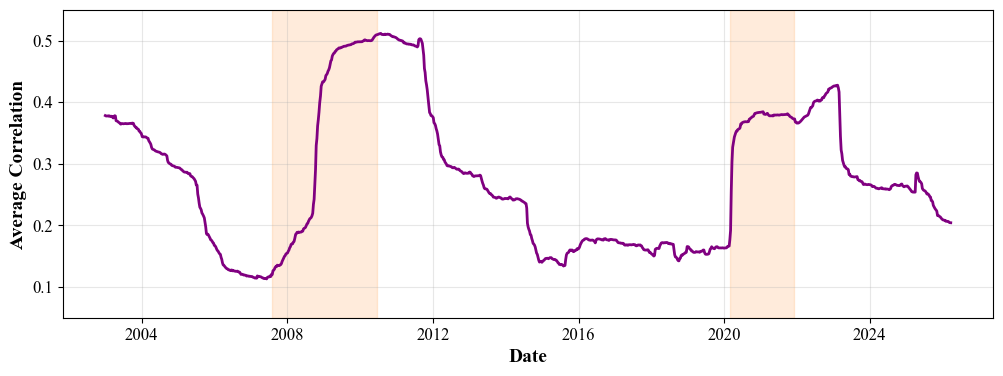

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(epoch_dates, mu_values, color="purple", label="Average Correlation", markersize=4, linewidth=2)
crisis_colours = ['#ff7f0e', '#ff7f0e']
for (label, (start, end)), colour in zip(crisis_periods.items(), crisis_colours):
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=colour, label=label)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.05, 0.55)
plt.xlabel("Date", fontsize=14, fontweight="bold")
plt.ylabel("Average Correlation", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.savefig("images_1/avg_corr_onefactor.png", bbox_inches="tight")
plt.show()

### MST Graph and Topological Properties

In [9]:
mst_graphs = []
central_nodes_mst = []

for D in distance_matrices:
    G_mst = mst_graph(D, stock_names)
    degree_dict = dict(G_mst.degree())
    central_node = max(degree_dict, key=degree_dict.get)
    central_nodes_mst.append(central_node)
    mst_graphs.append(G_mst)

In [10]:
survival_ratios_mst = []
previous_edges_mst = None

for G in mst_graphs:
    current_edges_mst = set(G.edges())
    if previous_edges_mst is not None:
        common_edges = current_edges_mst.intersection(previous_edges_mst)
        survival_ratio = len(common_edges) / len(current_edges_mst)
        survival_ratios_mst.append(survival_ratio)
    else:
        survival_ratios_mst.append(np.nan)
    previous_edges_mst = current_edges_mst

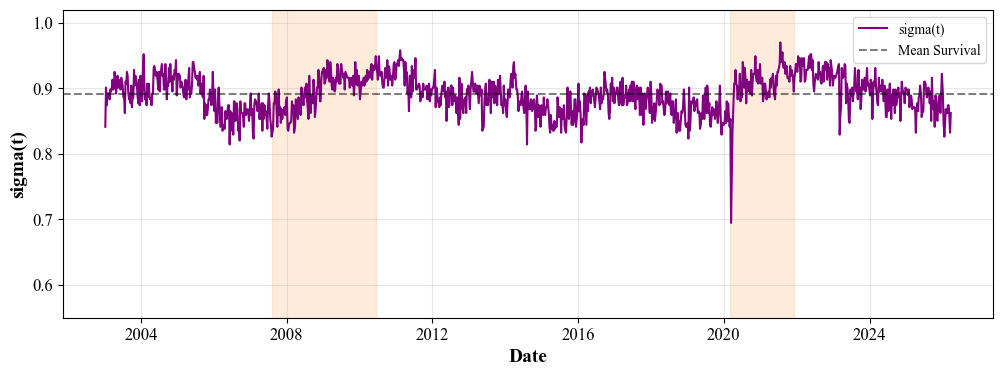

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(epoch_dates, survival_ratios_mst, color='purple', label='sigma(t)')
crisis_colours = ['#ff7f0e', '#ff7f0e']
for (label, (start, end)), colour in zip(crisis_periods.items(), crisis_colours):
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=colour)
plt.axhline(np.nanmean(survival_ratios_mst), color='black', linestyle='--', alpha=0.5, label='Mean Survival')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.55, 1.02)
plt.ylabel("sigma(t)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("images_1/survival_ratios_mst_onefactor.png", bbox_inches="tight")
plt.show()

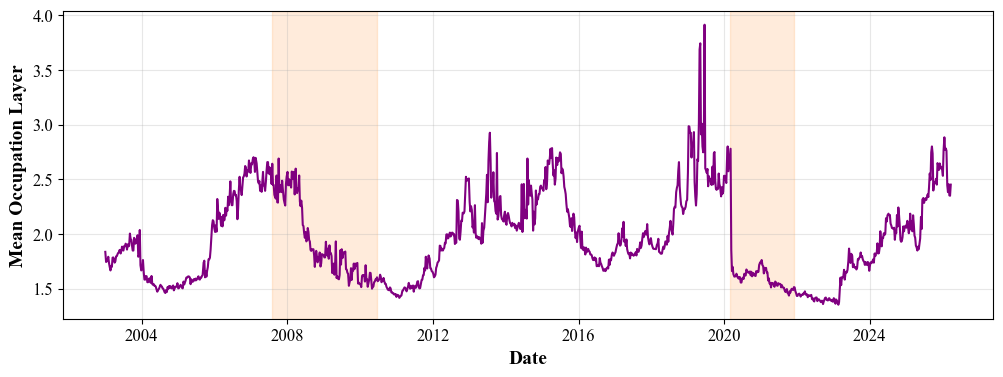

In [12]:
mol_mst = []
for G, central_node in zip(mst_graphs, central_nodes_mst):
    lengths = nx.single_source_shortest_path_length(G, central_node)
    mol = np.mean(list(lengths.values()))
    mol_mst.append(mol)

plt.figure(figsize=(12, 4))
plt.plot(epoch_dates, mol_mst, color="purple", label="MOL (MST)")
crisis_colours = ['#ff7f0e', '#ff7f0e']
for (label, (start, end)), colour in zip(crisis_periods.items(), crisis_colours):
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=colour)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Date", fontsize=14, fontweight="bold")
plt.ylabel("Mean Occupation Layer", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.savefig("images_1/mol_mst_onefactor.png", bbox_inches="tight")
plt.show()

### Portfolio Analysis

In [13]:
returns_windows = []

for i in range(0, len(df_onefactor_returns) - epoch_length, epoch_shift):
    epoch = df_onefactor_returns.iloc[i:i + epoch_length]
    returns_windows.append(epoch.iloc[:, 1:].values)

In [14]:
portfolio_layers_mst = []
portfolio_weights_mst = []
for t, (G, central_node) in enumerate(zip(mst_graphs, central_nodes_mst)):
    n = len(stock_names)
    
    cov_matrix = np.cov(returns_windows[t].T) + 1e-6 * np.eye(n)
    w = cp.Variable(n)
    problem = cp.Problem(cp.Minimize(cp.quad_form(w, cov_matrix)), [cp.sum(w) == 1, w >= 0])
    problem.solve(solver=cp.OSQP, verbose=False)
    weights = np.asarray(w.value).flatten() if w.value is not None else np.full(n, np.nan)
    portfolio_weights_mst.append(weights)

    lengths = nx.single_source_shortest_path_length(G, central_node)
    lP      = sum(weights[i] * lengths.get(stock_names[i], 0) for i in range(n) if not np.isnan(weights[i]))
    portfolio_layers_mst.append(lP)

portfolio_layers_mst  = np.array(portfolio_layers_mst)
portfolio_weights_mst = np.array(portfolio_weights_mst)

diff = portfolio_layers_mst - mol_mst
print(f"Mean MOL:                         {np.nanmean(mol_mst):.3f}")
print(f"Mean Portfolio Layer:             {np.nanmean(portfolio_layers_mst):.3f}")
print(f"Mean layer difference (lP - MOL): {np.nanmean(diff):.3f}")
print(f"Fraction of time lP > MOL:        {np.nanmean(diff > 0):.3f}")

Mean MOL:                         1.954
Mean Portfolio Layer:             2.327
Mean layer difference (lP - MOL): 0.373
Fraction of time lP > MOL:        0.924


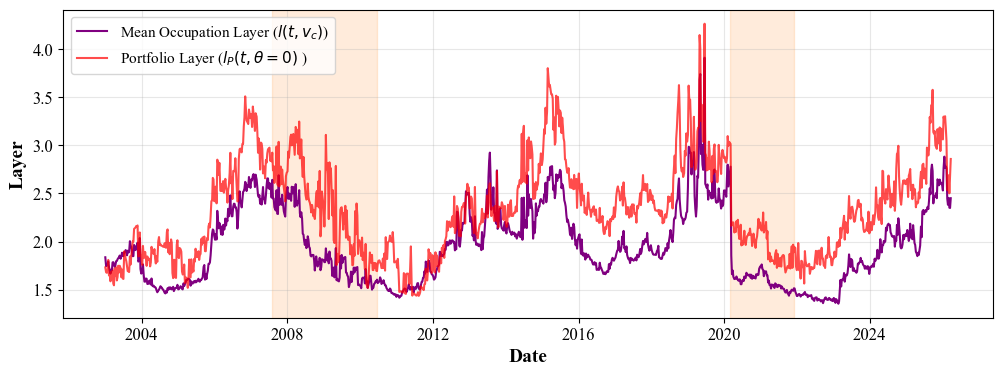

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(epoch_dates, mol_mst, color="purple", linewidth=1.5, label=r"Mean Occupation Layer ($l(t, v_c)$)")
plt.plot(epoch_dates, portfolio_layers_mst, color="red", alpha=0.7, linewidth=1.5, label=r"Portfolio Layer ($l_P(t, \theta=0)$ )")
crisis_colours = ['#ff7f0e', '#ff7f0e']
for (label, (start, end)), colour in zip(crisis_periods.items(), crisis_colours):
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=colour)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Date", fontsize=14, fontweight="bold")
plt.ylabel("Layer", fontsize=14, fontweight="bold")
plt.legend(fontsize=11, loc="upper left")
plt.grid(True, alpha=0.3)
plt.savefig("images_1/portfoliolayer_mol_mst_onefactor.png", bbox_inches="tight")
plt.show()